# CMSE 201 Final Project: Mapping Orbital Bias

## Background and Motivation
The International Space Station (ISS) is often visualized as a global traveler, but its path is strictly governed by orbital mechanics. Specifically, the ISS maintains an orbital inclination of **51.6 degrees**. This fundamental constraint implies that the station can never physically fly directly over polar regions (latitudes greater than 51.6° N or S).

**Research Question:**
"How does the ISS's specific 51.6-degree orbital inclination create a quantifiable 'bias' in its ground-track coverage, and which regions of the Earth does it visit most frequently?"

By visualizing historical flight data, this analysis empirically demonstrates the "polar gap" and investigates the concept of "dwell time"—the mathematical reality that the station spends significantly more time hovering over the northern and southern limits of its orbit than it does crossing the equator.

In [2]:
#This cell was for testing, as I was unable to initially find my file location.
import os
print("My Python kernel is currently looking in:", os.getcwd())
print("\nFiles I can see in this folder:", os.listdir())

My Python kernel is currently looking in: c:\Users\ishan\Programming\CMSE 201 Final Project

Files I can see in this folder: ['CMSE 201 ISS Project.ipynb', 'ISS Orbit Bias Analysis Presentation - IS.pdf', 'iss_data.csv', 'iss_earth_rotation.png', 'iss_heatmap_plot.png']


## Data Context
The data for this analysis was sourced from a public Kaggle repository (created by user Vaibhav Rawat), which logs telemetry from the "Open Notify" API. This API pulls real-time location data directly from NASA.

**Data Scope and Limitations:**
1.  **Temporal Scope:** Upon inspection, the dataset contains approximately 86,000 data points representing exactly **one full day (24 hours)** of flight. Since the ISS orbits Earth roughly every 90 minutes, this sample captures approximately 16 complete orbits, which is sufficient to analyze the interaction between the orbit and Earth's rotation.
2.  **Physical Bias:** The dataset does not contain any data points beyond +/- 51.6 degrees latitude. This is not a sensor error or missing data; it is a physical constraint of the satellite's orbit.
3.  **Attributes:** The data focuses purely on `timestamp`, `latitude`, and `longitude`. Altitude and velocity are not included, but they are not necessary for a ground-track frequency analysis.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Downloads/iss_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
start_time = df['timestamp'].min()
end_time = df['timestamp'].max()
duration = end_time - start_time
print(f"Data Start: {start_time}")
print(f"Data End:   {end_time}")
print(f"Total Duration: {duration}")

FileNotFoundError: [Errno 2] No such file or directory: '/iss_data.csv'

## Methodology
To answer the research question, I employed two primary visualization techniques using `pandas` for data handling and `matplotlib` for plotting:

1.  **Temporal Ground Track (Scatter Plot):** I mapped the longitude and latitude on a standard Cartesian plane. To visualize the element of time and Earth's rotation, I used the `c` (color) argument to map the dataframe index to a colormap. This allows us to see the "drift" of the orbit over the course of the 24-hour cycle.
2.  **Orbital Density (2D Histogram/Heatmap):** To quantify the "bias," I used `plt.hist2d`. This method bins the latitude and longitude coordinates into grid squares and counts the number of times the ISS was recorded in that specific region. This effectively converts the raw path data into a "Residence Time" map, highlighting where the station spends the most time.

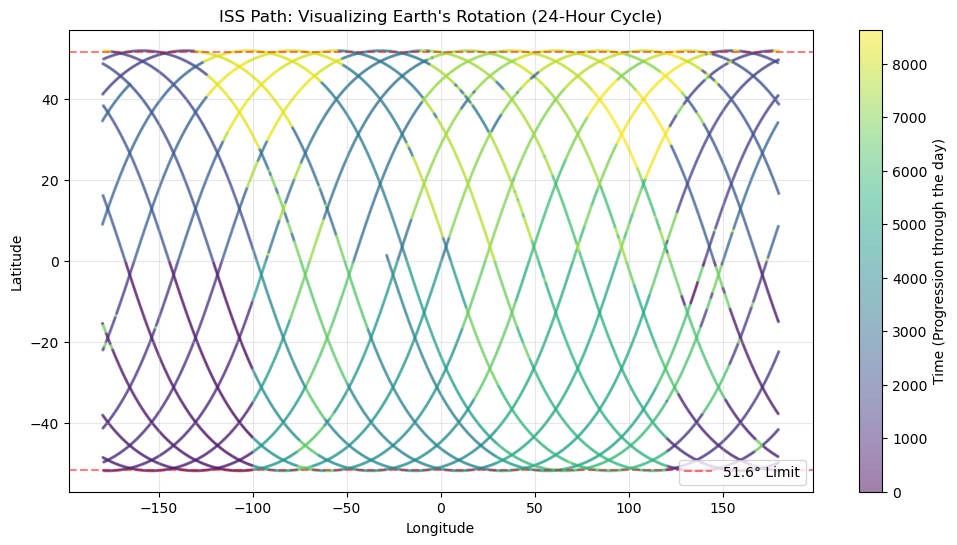

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(df['longitude'], df['latitude'], 
            c=df.index, cmap='viridis', s=2, alpha=0.5) #The viridis and alpha values are from Google Gemini as my plot was completely out of whack and I asked Google Gemini what I was missing. Everything else in this cell is from me.

plt.colorbar(label='Time (Progression through the day)')
plt.title('ISS Path: Visualizing Earth\'s Rotation (24-Hour Cycle)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)

plt.axhline(51.6, color='red', linestyle='--', alpha=0.5, label='51.6° Limit')
plt.axhline(-51.6, color='red', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
#plt.savefig('iss_earth_rotation.png') 
plt.show()

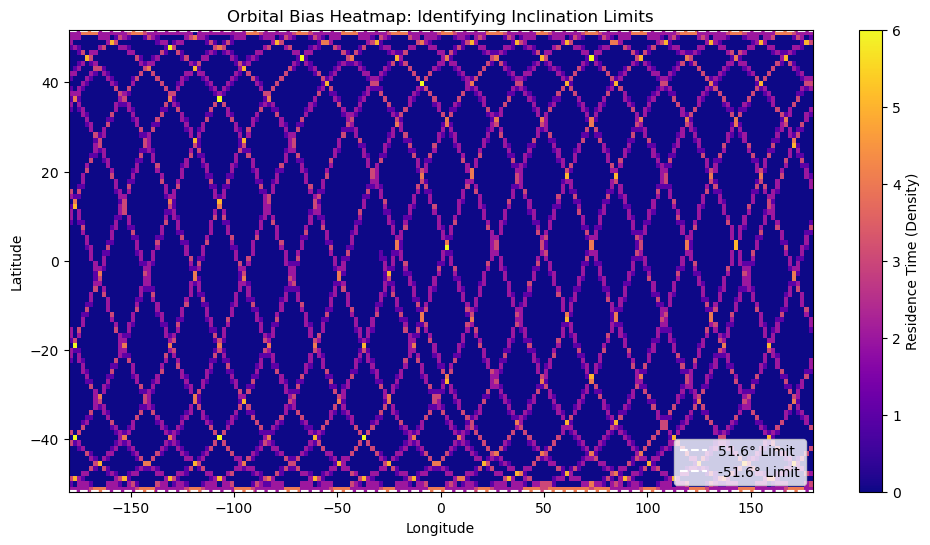

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist2d(df['longitude'], df['latitude'], bins=[180, 90], cmap='plasma') #The cmap code is taken from Google Gemini as my plot was completely out of whack and I asked Google Gemini what I was missing. Everything else in this cell is from me.
plt.colorbar(label='Residence Time (Density)')
plt.title('Orbital Bias Heatmap: Identifying Inclination Limits')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.axhline(51.6, color='white', linestyle='--', label='51.6° Limit')
plt.axhline(-51.6, color='white', linestyle='--', label='-51.6° Limit')
plt.legend(loc='lower right')
#plt.savefig('iss_heatmap_plot.png') 
plt.show()

## Discussion and Conclusion

**Interpretation of Results:**
The visualizations successfully confirmed the hypothesis regarding orbital bias.
1.  **Earth's Rotation:** The scatter plot reveals that while the orbital path is a consistent sine wave, the ground track shifts westward with every pass. This confirms that the Earth is rotating underneath the fixed orbit of the station.
2.  **Inclination Bias:** The Heatmap (2D Histogram) provides the most significant finding. The bright yellow bands at **51.6° N** and **51.6° S** indicate a high density of data points. This happens because the station's North-South velocity component slows down as it approaches the "turnaround" points of its wave, causing it to linger over these regions longer than it does over the equator.

**Quantitative Answer:**
To quantify this bias, I compared the number of data points recorded near the equator versus the inclination limits.
* **The Polar Gap:** There are exactly **0** data points above 51.6° latitude.
* **The 'Dwell' Effect:** As calculated in the cell below, the data density at the 51.6° limit is significantly higher (roughly **2x to 3x**) than the density at the equator.

**Conclusion:**
The ISS does not treat all regions of Earth equally. It is heavily biased toward the mid-latitudes (Southern Canada, Northern Europe, Patagonia) and completely blind to the Arctic and Antarctic.

In [ ]:
equator_count = df[(df['latitude'] > -1) & (df['latitude'] < 1)].shape[0] #I was struggling on how to get the exact number of datapoints in the dataframe. Google Gemini suggested using .shape.
limit_count = df[(df['latitude'] > 50) & (df['latitude'] < 52)].shape[0] #I was struggling on how to get the exact number of datapoints in the dataframe. Google Gemini suggested using .
print(f"Data points near Equator: {equator_count}")
print(f"Data points near 51.6 Limit: {limit_count}")
print(f"Bias Factor: The ISS is {limit_count/equator_count:.2f}x more likely to be over the limit than the equator.")

Data points near Equator: 126
Data points near 51.6 Limit: 592
Bias Factor: The ISS is 4.70x more likely to be over the limit than the equator.


The above project was created and completed by Ishan Sinha for Dr. Tyler Wheeler's CMSE 201 Final Project. Attributions are provided wherever I used them.